# ML v1.4 - сравнение CatBoost и LightGBM по Top-5000 score

Notebook пересчитывает top-5000 клиентов для сохранённой CatBoost long-run модели из `v1.1` и сравнивает shape fraud risk-score с текущей лучшей LightGBM моделью из `v1.4`. На графике будет четыре линии: CatBoost all, CatBoost test, LightGBM all, LightGBM test.

In [3]:
from pathlib import Path
import sys
import subprocess
import importlib.util
import warnings

warnings.filterwarnings("ignore")

for package_name, import_name in [
    ("catboost", "catboost"),
    ("matplotlib", "matplotlib"),
    ("scikit-learn", "sklearn"),
    ("lightgbm", "lightgbm"),
    ("joblib", "joblib"),
]:
    if importlib.util.find_spec(import_name) is None:
        print(f"{package_name} не найден. Устанавливаю...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"{package_name} уже установлен.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 240)

catboost уже установлен.
matplotlib уже установлен.
scikit-learn уже установлен.
lightgbm уже установлен.
joblib уже установлен.


In [4]:
def first_existing(candidates, recursive_patterns=()):
    for candidate in candidates:
        p = Path(candidate)
        if p.exists():
            return p
    for root, pattern in recursive_patterns:
        root = Path(root)
        if root.exists():
            matches = sorted(root.glob(pattern))
            if matches:
                return matches[0]
    return None

IS_KAGGLE = Path("/kaggle/working").exists()
IS_COLAB = Path("/content").exists()
LOCAL_ROOT = Path.cwd()

if IS_KAGGLE:
    OUTPUT_DIR = Path("/kaggle/working/ML/1.4/results_score_compare")
elif Path("/content/drive/MyDrive/ieee-db").exists():
    OUTPUT_DIR = Path("/content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare")
else:
    OUTPUT_DIR = LOCAL_ROOT / "ML" / "1.4" / "results_score_compare"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = first_existing(
    candidates=[
        LOCAL_ROOT / "client_profile_v1_0_shuffled.csv",
        Path("/content/drive/MyDrive/ieee-db/client_profile_v1_0_shuffled.csv"),
        Path("/kaggle/working/client_profile_v1_0_shuffled.csv"),
    ],
    recursive_patterns=[
        ("/kaggle/input", "**/client_profile_v1_0_shuffled.csv"),
        ("/content/drive/MyDrive", "**/client_profile_v1_0_shuffled.csv"),
    ],
)

CATBOOST_MODEL_FILE = first_existing(
    candidates=[
        LOCAL_ROOT / "ML/1.1/results_longrung/ml_v1_1_longrun_best_catboost.cbm",
        Path("/content/drive/MyDrive/ieee-db/ML/1.1/results_longrung/ml_v1_1_longrun_best_catboost.cbm"),
        Path("/kaggle/working/ML/1.1/results_longrung/ml_v1_1_longrun_best_catboost.cbm"),
    ],
    recursive_patterns=[
        ("/kaggle/input", "**/ml_v1_1_longrun_best_catboost.cbm"),
        ("/content/drive/MyDrive", "**/ml_v1_1_longrun_best_catboost.cbm"),
    ],
)

LGBM_ALL_FILE = first_existing(
    candidates=[
        LOCAL_ROOT / "ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_clients_by_pr_auc_model.csv",
        Path("/content/drive/MyDrive/ieee-db/ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_clients_by_pr_auc_model.csv"),
        Path("/kaggle/working/ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_clients_by_pr_auc_model.csv"),
    ],
    recursive_patterns=[
        ("/kaggle/input", "**/ml_v1_4_top5000_clients_by_pr_auc_model.csv"),
        ("/kaggle/working", "**/ml_v1_4_top5000_clients_by_pr_auc_model.csv"),
        ("/content/drive/MyDrive", "**/ml_v1_4_top5000_clients_by_pr_auc_model.csv"),
    ],
)

LGBM_TEST_FILE = first_existing(
    candidates=[
        LOCAL_ROOT / "ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_test_clients_by_pr_auc_model.csv",
        LOCAL_ROOT / "ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_test_clients_by_roc_auc_model.csv",
        Path("/content/drive/MyDrive/ieee-db/ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_test_clients_by_pr_auc_model.csv"),
        Path("/content/drive/MyDrive/ieee-db/ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_test_clients_by_roc_auc_model.csv"),
        Path("/kaggle/working/ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_test_clients_by_pr_auc_model.csv"),
        Path("/kaggle/working/ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_test_clients_by_roc_auc_model.csv"),
    ],
    recursive_patterns=[
        ("/kaggle/input", "**/ml_v1_4_top5000_test_clients_by_pr_auc_model.csv"),
        ("/kaggle/input", "**/ml_v1_4_top5000_test_clients_by_roc_auc_model.csv"),
        ("/kaggle/working", "**/ml_v1_4_top5000_test_clients_by_pr_auc_model.csv"),
        ("/kaggle/working", "**/ml_v1_4_top5000_test_clients_by_roc_auc_model.csv"),
        ("/content/drive/MyDrive", "**/ml_v1_4_top5000_test_clients_by_pr_auc_model.csv"),
        ("/content/drive/MyDrive", "**/ml_v1_4_top5000_test_clients_by_roc_auc_model.csv"),
    ],
)

LGBM_MODEL_FILE = first_existing(
    candidates=[
        LOCAL_ROOT / "ML/1.4/results_lightgbm_confirm/ml_v1_4_best_by_pr_auc.joblib",
        LOCAL_ROOT / "ML/1.4/results_lightgbm_confirm/ml_v1_4_best_by_roc_auc.joblib",
        Path("/content/drive/MyDrive/ieee-db/ML/1.4/results_lightgbm_confirm/ml_v1_4_best_by_pr_auc.joblib"),
        Path("/content/drive/MyDrive/ieee-db/ML/1.4/results_lightgbm_confirm/ml_v1_4_best_by_roc_auc.joblib"),
        Path("/kaggle/working/ML/1.4/results_lightgbm_confirm/ml_v1_4_best_by_pr_auc.joblib"),
        Path("/kaggle/working/ML/1.4/results_lightgbm_confirm/ml_v1_4_best_by_roc_auc.joblib"),
    ],
    recursive_patterns=[
        ("/kaggle/input", "**/ml_v1_4_best_by_pr_auc.joblib"),
        ("/kaggle/input", "**/ml_v1_4_best_by_roc_auc.joblib"),
        ("/kaggle/working", "**/ml_v1_4_best_by_pr_auc.joblib"),
        ("/kaggle/working", "**/ml_v1_4_best_by_roc_auc.joblib"),
        ("/content/drive/MyDrive", "**/ml_v1_4_best_by_pr_auc.joblib"),
        ("/content/drive/MyDrive", "**/ml_v1_4_best_by_roc_auc.joblib"),
    ],
)

print("Файл данных:", DATA_FILE)
print("CATBOOST_MODEL_FILE:", CATBOOST_MODEL_FILE)
print("LGBM_ALL_FILE:", LGBM_ALL_FILE)
print("LGBM_TEST_FILE:", LGBM_TEST_FILE)
print("LGBM_MODEL_FILE:", LGBM_MODEL_FILE)
print("OUTPUT_DIR:", OUTPUT_DIR)

missing = [name for name, value in {
    "DATA_FILE": DATA_FILE,
    "CATBOOST_MODEL_FILE": CATBOOST_MODEL_FILE,
    "LGBM_ALL_FILE": LGBM_ALL_FILE,
    "LGBM_TEST_FILE": LGBM_TEST_FILE,
    "LGBM_MODEL_FILE": LGBM_MODEL_FILE,
}.items() if value is None]
if missing:
    raise FileNotFoundError("Не найдены файлы: " + ", ".join(missing))

Файл данных: /content/drive/MyDrive/ieee-db/client_profile_v1_0_shuffled.csv
CATBOOST_MODEL_FILE: /content/drive/MyDrive/ieee-db/ml_v1_1_longrun_best_catboost.cbm
LGBM_ALL_FILE: /content/drive/MyDrive/ieee-db/ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_clients_by_pr_auc_model.csv
LGBM_TEST_FILE: /content/drive/MyDrive/ieee-db/ML/1.4/results_lightgbm_confirm/ml_v1_4_top5000_test_clients_by_pr_auc_model.csv
LGBM_MODEL_FILE: /content/drive/MyDrive/ieee-db/ML/1.4/results_lightgbm_confirm/ml_v1_4_best_by_pr_auc.joblib
OUTPUT_DIR: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare


In [5]:
df = pd.read_csv(DATA_FILE)
print("Размер таблицы:", df.shape)

TARGET_COL = "profile_fraud_label"
ID_COLS = ["client_id"]
LEAKY_COLS = [c for c in ["tx_count_fraud", "fraud_rate"] if c in df.columns]
HIGH_MISSING_THRESHOLD = 0.95

high_missing_cols = [
    c for c in df.columns
    if c not in [TARGET_COL] + ID_COLS and df[c].isna().mean() > HIGH_MISSING_THRESHOLD
]
feature_drop_cols = ID_COLS + LEAKY_COLS + high_missing_cols

X = df.drop(columns=[c for c in feature_drop_cols + [TARGET_COL] if c in df.columns]).copy()
y = df[TARGET_COL].astype(int).copy()

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print("Удаляем из признаков:", feature_drop_cols)
print("Осталось признаков:", X.shape[1])
print("Категориальные колонки:", categorical_cols)
print("Доля fraud:", float(y.mean()))

Размер таблицы: (174280, 95)
Удаляем из признаков: ['client_id', 'id_07_mean', 'id_07_median', 'id_08_mean', 'id_08_median', 'id_21_mode', 'id_22_mode', 'id_23_mode', 'id_24_mode', 'id_25_mode', 'id_26_mode', 'id_27_mode']
Осталось признаков: 82
Категориальные колонки: ['card4_mode', 'card6_mode', 'top_email_domain', 'id_12_mode', 'id_15_mode', 'id_16_mode', 'id_28_mode', 'id_29_mode', 'id_30_mode', 'id_31_mode', 'id_33_mode', 'id_34_mode', 'id_35_mode', 'id_36_mode', 'id_37_mode', 'id_38_mode']
Доля fraud: 0.03726761533165022


In [6]:
# Восстанавливаем тот же train/val/test split, что в v1.1/v1.4.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.1764705882,
    random_state=42,
    stratify=y_train_val,
)

split_map = pd.Series("unknown", index=df.index, dtype="object")
split_map.loc[X_train.index] = "train"
split_map.loc[X_val.index] = "val"
split_map.loc[X_test.index] = "test"

print("Train:", X_train.shape, "fraud rate:", float(y_train.mean()))
print("Val:", X_val.shape, "fraud rate:", float(y_val.mean()))
print("Test:", X_test.shape, "fraud rate:", float(y_test.mean()))
print(split_map.value_counts())

Train: (121996, 82) fraud rate: 0.037271713826682845
Val: (26142, 82) fraud rate: 0.037258052176574095
Test: (26142, 82) fraud rate: 0.037258052176574095
train    121996
val       26142
test      26142
Name: count, dtype: int64


In [7]:
def prepare_catboost_frame(frame):
    out = frame.copy()
    for c in categorical_cols:
        out[c] = out[c].astype("object").where(out[c].notna(), "MISSING").astype(str)
    return out

cat_feature_indices = [X.columns.get_loc(c) for c in categorical_cols]

catboost_model = CatBoostClassifier()
catboost_model.load_model(str(CATBOOST_MODEL_FILE))
print("CatBoost model loaded:", CATBOOST_MODEL_FILE)

X_all_cb = prepare_catboost_frame(X)
all_pool = Pool(X_all_cb, cat_features=cat_feature_indices)
catboost_scores = catboost_model.predict_proba(all_pool)[:, 1]

print("CatBoost score range:", float(catboost_scores.min()), float(catboost_scores.max()))

CatBoost model loaded: /content/drive/MyDrive/ieee-db/ml_v1_1_longrun_best_catboost.cbm
CatBoost score range: 0.000213421049378393 0.999790543727777


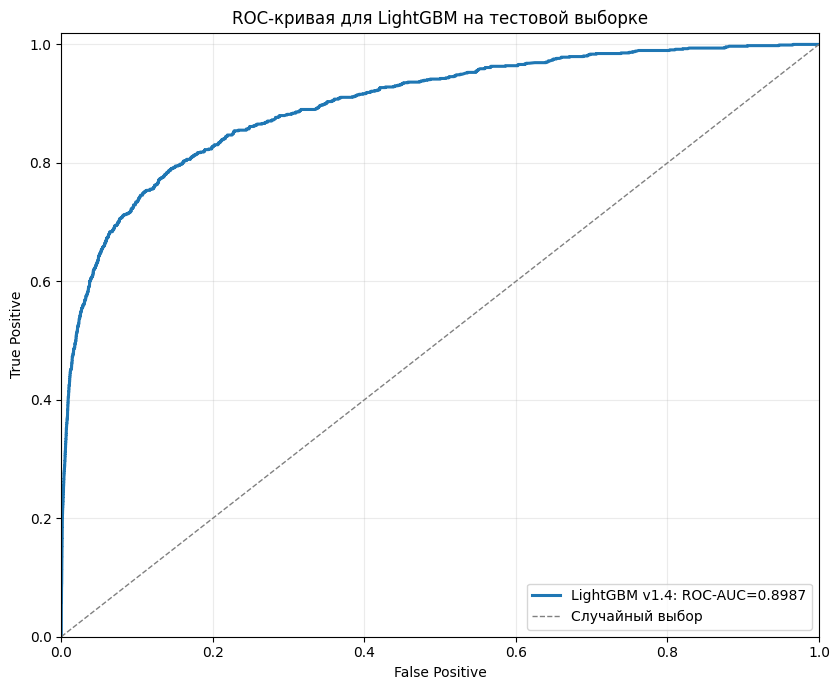

ROC curve data сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_roc_curve_test.csv
ROC plot сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_roc_curve_test.png
ROC plot сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_roc_curve_test.svg
CatBoost ROC-AUC: 0.8902594890875413 PR-AUC: 0.47082686773559745
LightGBM ROC-AUC: 0.8986526557957629 PR-AUC: 0.4966652740942851


In [16]:
# ROC-кривая требует score по всему test, а не только Top-5000.
# LightGBM загружается из joblib bundle вместе с preprocessor.
catboost_score_series = pd.Series(catboost_scores, index=X.index, name="catboost_score")
catboost_test_scores = catboost_score_series.loc[X_test.index].to_numpy()

lgbm_bundle = joblib.load(LGBM_MODEL_FILE)
lightgbm_model = lgbm_bundle["model"]
lightgbm_preprocessor = lgbm_bundle["preprocessor"]
lightgbm_features = lgbm_bundle.get("features", X.columns.tolist())
lightgbm_model_name = lgbm_bundle.get("model_name", "lightgbm_v1_4_best")

missing_lgbm_features = [c for c in lightgbm_features if c not in df.columns]
if missing_lgbm_features:
    raise ValueError("В df не найдены признаки LightGBM: " + ", ".join(missing_lgbm_features[:20]))

X_lgbm_all = df.loc[X.index, lightgbm_features].copy()
X_lgbm_test = X_lgbm_all.loc[X_test.index]
lightgbm_test_scores = lightgbm_model.predict_proba(lightgbm_preprocessor.transform(X_lgbm_test))[:, 1]

y_test_for_roc = y.loc[X_test.index].to_numpy()

cat_fpr, cat_tpr, cat_thresholds = roc_curve(y_test_for_roc, catboost_test_scores)
lgbm_fpr, lgbm_tpr, lgbm_thresholds = roc_curve(y_test_for_roc, lightgbm_test_scores)

cat_roc_auc = roc_auc_score(y_test_for_roc, catboost_test_scores)
lgbm_roc_auc = roc_auc_score(y_test_for_roc, lightgbm_test_scores)
cat_pr_auc = average_precision_score(y_test_for_roc, catboost_test_scores)
lgbm_pr_auc = average_precision_score(y_test_for_roc, lightgbm_test_scores)

roc_df = pd.concat([
    pd.DataFrame({"model": "CatBoost v1.1 longrun", "fpr": cat_fpr, "tpr": cat_tpr, "threshold": cat_thresholds}),
    pd.DataFrame({"model": f"LightGBM v1.4 ({lightgbm_model_name})", "fpr": lgbm_fpr, "tpr": lgbm_tpr, "threshold": lgbm_thresholds}),
], ignore_index=True)
roc_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_roc_curve_test.csv"
roc_df.to_csv(roc_path, index=False)

plt.figure(figsize=(8.5, 7))
# plt.plot(cat_fpr, cat_tpr, linewidth=2.2, label=f"CatBoost v1.1 longrun: ROC-AUC={cat_roc_auc:.4f}, PR-AUC={cat_pr_auc:.4f}")
plt.plot(lgbm_fpr, lgbm_tpr, linewidth=2.2, label=f"LightGBM v1.4: ROC-AUC={lgbm_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linewidth=1, linestyle="--", label="Случайный выбор")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-кривая для LightGBM на тестовой выборке")
plt.grid(True, alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()

roc_png_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_roc_curve_test.png"
roc_svg_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_roc_curve_test.svg"
plt.savefig(roc_png_path, dpi=180)
plt.savefig(roc_svg_path)
plt.show()

print("ROC curve data сохранено в:", roc_path)
print("ROC plot сохранено в:", roc_png_path)
print("ROC plot сохранено в:", roc_svg_path)
print("CatBoost ROC-AUC:", cat_roc_auc, "PR-AUC:", cat_pr_auc)
print("LightGBM ROC-AUC:", lgbm_roc_auc, "PR-AUC:", lgbm_pr_auc)

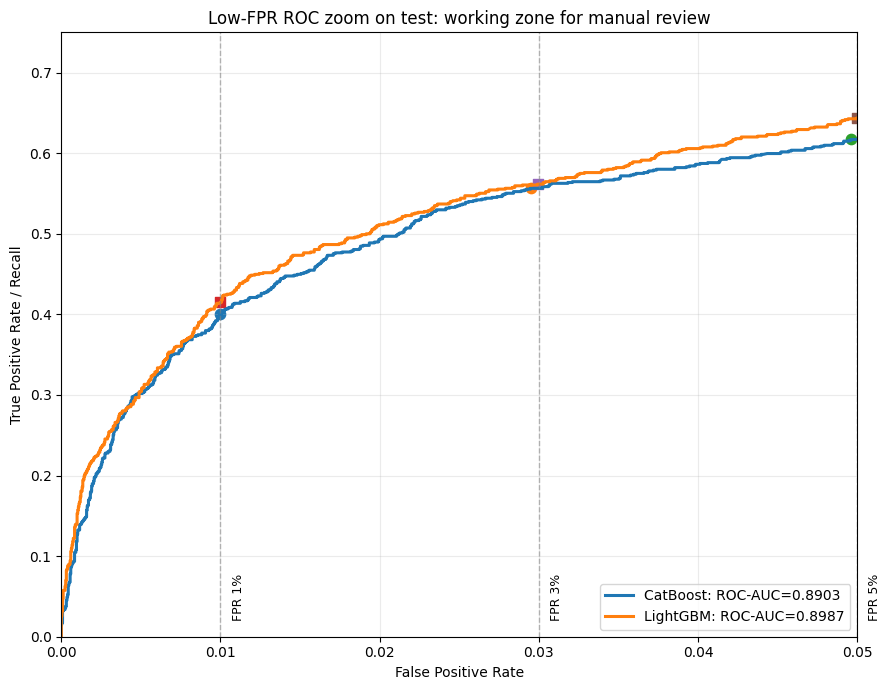

Low-FPR ROC curve data сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_low_fpr_roc_curve_test.csv
Low-FPR operating points сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_low_fpr_operating_points.csv
Low-FPR ROC zoom сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_low_fpr_roc_zoom_test.png
Low-FPR ROC zoom сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_low_fpr_roc_zoom_test.svg


,model,target_fpr,actual_fpr,recall_at_fpr,precision_at_fpr,threshold,pred_positive_rate,pred_positive_count
0,CatBoost v1.1 longrun,0.01,0.009973,0.400411,0.608424,0.875793,0.024520,641
1,CatBoost v1.1 longrun,0.03,0.029482,0.556468,0.422118,0.731544,0.049116,1284
2,CatBoost v1.1 longrun,0.05,0.049627,0.617043,0.324865,0.635124,0.070767,1850
3,LightGBM v1.4 (lgbm_auc_unweighted_seed2026),0.01,0.009973,0.414784,0.616794,0.304881,0.025055,655
4,LightGBM v1.4 (lgbm_auc_unweighted_seed2026),0.03,0.029919,0.561602,0.420769,0.136345,0.049728,1300
5,LightGBM v1.4 (lgbm_auc_unweighted_seed2026),0.05,0.049984,0.643737,0.332626,0.091291,0.072106,1885


In [9]:
# Low-FPR ROC показывает режим с малой долей ложных срабатываний.
# Смотрим рабочую зону FPR <= 5% и отдельно точки FPR 1%, 3%, 5%.
FPR_TARGETS_FOR_BUSINESS = [0.01, 0.03, 0.05]
LOW_FPR_MAX = 0.05


def operating_points_from_roc(model_name, fpr, tpr, thresholds, y_true, y_score, targets):
    rows = []
    for target_fpr in targets:
        valid = np.where(fpr <= target_fpr)[0]
        if len(valid) == 0:
            idx = int(np.argmin(fpr))
        else:
            idx = int(valid[np.argmax(tpr[valid])])
        threshold = float(thresholds[idx])
        pred = (y_score >= threshold).astype(int)
        precision = float(np.sum((pred == 1) & (y_true == 1)) / max(np.sum(pred == 1), 1))
        rows.append({
            "model": model_name,
            "target_fpr": target_fpr,
            "actual_fpr": float(fpr[idx]),
            "recall_at_fpr": float(tpr[idx]),
            "precision_at_fpr": precision,
            "threshold": threshold,
            "pred_positive_rate": float(pred.mean()),
            "pred_positive_count": int(pred.sum()),
        })
    return rows

low_fpr_rows = []
low_fpr_rows.extend(operating_points_from_roc(
    "CatBoost v1.1 longrun",
    cat_fpr,
    cat_tpr,
    cat_thresholds,
    y_test_for_roc,
    catboost_test_scores,
    FPR_TARGETS_FOR_BUSINESS,
))
low_fpr_rows.extend(operating_points_from_roc(
    f"LightGBM v1.4 ({lightgbm_model_name})",
    lgbm_fpr,
    lgbm_tpr,
    lgbm_thresholds,
    y_test_for_roc,
    lightgbm_test_scores,
    FPR_TARGETS_FOR_BUSINESS,
))
low_fpr_ops_df = pd.DataFrame(low_fpr_rows)
low_fpr_ops_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_low_fpr_operating_points.csv"
low_fpr_ops_df.to_csv(low_fpr_ops_path, index=False)

low_fpr_curve_df = roc_df[roc_df["fpr"] <= LOW_FPR_MAX].copy()
low_fpr_curve_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_low_fpr_roc_curve_test.csv"
low_fpr_curve_df.to_csv(low_fpr_curve_path, index=False)

plt.figure(figsize=(9, 7))
plt.plot(cat_fpr, cat_tpr, linewidth=2.2, label=f"CatBoost: ROC-AUC={cat_roc_auc:.4f}")
plt.plot(lgbm_fpr, lgbm_tpr, linewidth=2.2, label=f"LightGBM: ROC-AUC={lgbm_roc_auc:.4f}")
for target_fpr in FPR_TARGETS_FOR_BUSINESS:
    plt.axvline(target_fpr, color="gray", linewidth=1, linestyle="--", alpha=0.55)
    plt.text(target_fpr + 0.0007, 0.02, f"FPR {target_fpr:.0%}", rotation=90, va="bottom", fontsize=9)

for _, row in low_fpr_ops_df.iterrows():
    marker = "o" if row["model"].startswith("CatBoost") else "s"
    plt.scatter(row["actual_fpr"], row["recall_at_fpr"], s=55, marker=marker)

plt.xlim(0, LOW_FPR_MAX)
plt.ylim(0, 0.75)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Low-FPR ROC zoom on test: working zone for manual review")
plt.grid(True, alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()

low_fpr_png_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_low_fpr_roc_zoom_test.png"
low_fpr_svg_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_low_fpr_roc_zoom_test.svg"
plt.savefig(low_fpr_png_path, dpi=180)
plt.savefig(low_fpr_svg_path)
plt.show()

print("Low-FPR ROC curve data сохранено в:", low_fpr_curve_path)
print("Low-FPR operating points сохранено в:", low_fpr_ops_path)
print("Low-FPR ROC zoom сохранено в:", low_fpr_png_path)
print("Low-FPR ROC zoom сохранено в:", low_fpr_svg_path)
display(low_fpr_ops_df)

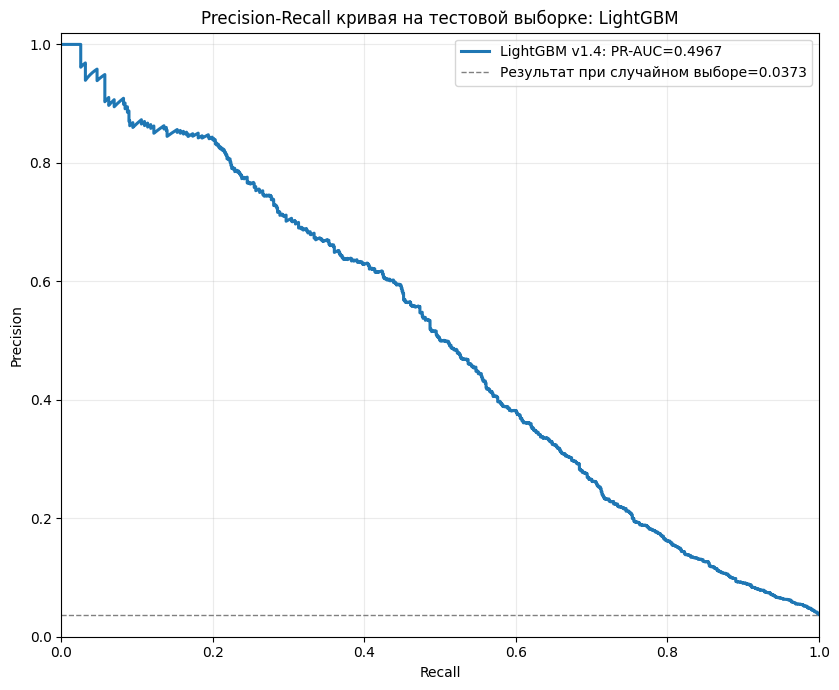

PR curve data сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_pr_curve_test.csv
PR plot сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_pr_curve_test.png
PR plot сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_pr_curve_test.svg
CatBoost PR-AUC: 0.47082686773559745
LightGBM PR-AUC: 0.4966652740942851


In [10]:
# Precision-Recall curve по всему test - основная кривая для редкого fraud-класса.
cat_precision, cat_recall, cat_pr_thresholds = precision_recall_curve(y_test_for_roc, catboost_test_scores)
lgbm_precision, lgbm_recall, lgbm_pr_thresholds = precision_recall_curve(y_test_for_roc, lightgbm_test_scores)

cat_pr_auc = average_precision_score(y_test_for_roc, catboost_test_scores)
lgbm_pr_auc = average_precision_score(y_test_for_roc, lightgbm_test_scores)

# У PR-кривой thresholds на один элемент короче, поэтому последняя точка сохраняется с NaN.
cat_thresholds_padded = np.append(cat_pr_thresholds, np.nan)
lgbm_thresholds_padded = np.append(lgbm_pr_thresholds, np.nan)

pr_df = pd.concat([
    pd.DataFrame({
        "model": "CatBoost v1.1 longrun",
        "precision": cat_precision,
        "recall": cat_recall,
        "threshold": cat_thresholds_padded,
    }),
    pd.DataFrame({
        "model": f"LightGBM v1.4 ({lightgbm_model_name})",
        "precision": lgbm_precision,
        "recall": lgbm_recall,
        "threshold": lgbm_thresholds_padded,
    }),
], ignore_index=True)
pr_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_pr_curve_test.csv"
pr_df.to_csv(pr_path, index=False)

baseline_precision = float(np.mean(y_test_for_roc))

plt.figure(figsize=(8.5, 7))
# plt.plot(cat_recall, cat_precision, linewidth=2.2, label=f"CatBoost v1.1 longrun: PR-AUC={cat_pr_auc:.4f}")
plt.plot(lgbm_recall, lgbm_precision, linewidth=2.2, label=f"LightGBM v1.4: PR-AUC={lgbm_pr_auc:.4f}")
plt.axhline(baseline_precision, color="gray", linewidth=1, linestyle="--", label=f"Результат при случайном выборе={baseline_precision:.4f}")
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall кривая на тестовой выборке: LightGBM")
plt.grid(True, alpha=0.25)
plt.legend(loc="upper right")
plt.tight_layout()

pr_png_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_pr_curve_test.png"
pr_svg_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_pr_curve_test.svg"
plt.savefig(pr_png_path, dpi=180)
plt.savefig(pr_svg_path)
plt.show()

print("PR curve data сохранено в:", pr_path)
print("PR plot сохранено в:", pr_png_path)
print("PR plot сохранено в:", pr_svg_path)
print("CatBoost PR-AUC:", cat_pr_auc)
print("LightGBM PR-AUC:", lgbm_pr_auc)

In [11]:
OPTIONAL_CONTEXT_COLS = [
    "tx_count_total",
    "tx_amount_sum",
    "tx_amount_mean",
    "tx_freq_per_day",
    "top_email_domain",
    "identity_present",
    "low_history_flag",
    "history_support_score",
]


def build_scored_frame(scores, model_name):
    scored = pd.DataFrame({
        "client_id": df.loc[X.index, "client_id"].values if "client_id" in df.columns else X.index.astype(str),
        "fraud_risk_score": scores,
        "profile_fraud_label": y.loc[X.index].values,
        "split": split_map.loc[X.index].values,
        "model_name": model_name,
    }, index=X.index)
    for col in OPTIONAL_CONTEXT_COLS:
        if col in df.columns:
            scored[col] = df.loc[X.index, col].values
    scored = scored.sort_values("fraud_risk_score", ascending=False).reset_index(drop=False)
    scored = scored.rename(columns={"index": "source_row_index"})
    scored.insert(0, "rank", np.arange(1, len(scored) + 1))
    return scored

catboost_scored = build_scored_frame(catboost_scores, "catboost_v1_1_longrun")
catboost_top5000_all = catboost_scored.head(5000).copy()
catboost_top5000_test = catboost_scored[catboost_scored["split"] == "test"].head(5000).copy()

catboost_all_path = OUTPUT_DIR / "ml_v1_4_catboost_top5000_clients.csv"
catboost_test_path = OUTPUT_DIR / "ml_v1_4_catboost_top5000_test_clients.csv"
catboost_top5000_all.to_csv(catboost_all_path, index=False)
catboost_top5000_test.to_csv(catboost_test_path, index=False)

print("CatBoost top5000 all сохранено в:", catboost_all_path)
print("CatBoost top5000 test сохранено в:", catboost_test_path)
print("CatBoost top5000 all fraud rate:", float(catboost_top5000_all["profile_fraud_label"].mean()))
print("CatBoost top5000 test fraud rate:", float(catboost_top5000_test["profile_fraud_label"].mean()))
display(catboost_top5000_all.head(10))

CatBoost top5000 all сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_top5000_clients.csv
CatBoost top5000 test сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_top5000_test_clients.csv
CatBoost top5000 all fraud rate: 0.659
CatBoost top5000 test fraud rate: 0.1542


,rank,source_row_index,client_id,fraud_risk_score,profile_fraud_label,split,model_name,tx_count_total,tx_amount_sum,tx_amount_mean,tx_freq_per_day,top_email_domain,identity_present,low_history_flag,history_support_score
0,1,85900,10069_441.0_45,0.999791,1,val,catboost_v1_1_longrun,1,300.0,300.0,1.0,mail.com,1,1,0.1
1,2,71280,15066_251.0_45,0.999732,1,train,catboost_v1_1_longrun,2,600.0,300.0,2.0,mail.com,1,1,0.2
2,3,43226,10486_441.0_114,0.999637,1,train,catboost_v1_1_longrun,1,325.0,325.0,1.0,mail.com,1,1,0.1
3,4,61730,12686_327.0_134,0.999588,1,train,catboost_v1_1_longrun,1,300.0,300.0,1.0,outlook.com,1,1,0.1
4,5,111320,10145_387.0_75,0.999549,1,train,catboost_v1_1_longrun,1,450.0,450.0,1.0,gmail.com,1,1,0.1
5,6,89369,3682_225.0_109,0.999525,1,train,catboost_v1_1_longrun,1,500.0,500.0,1.0,gmail.com,1,1,0.1
6,7,68901,16075_123.0_174,0.999507,1,train,catboost_v1_1_longrun,1,500.0,500.0,1.0,outlook.com,1,1,0.1
7,8,152465,10486_472.0_114,0.999491,1,test,catboost_v1_1_longrun,1,325.0,325.0,1.0,mail.com,1,1,0.1
8,9,42258,3682_264.0_70,0.999458,1,train,catboost_v1_1_longrun,1,275.0,275.0,1.0,gmail.com,1,1,0.1
9,10,34161,16075_264.0_175,0.999417,1,val,catboost_v1_1_longrun,1,500.0,500.0,1.0,gmail.com,1,1,0.1


In [12]:
lightgbm_top5000_all = pd.read_csv(LGBM_ALL_FILE)
lightgbm_top5000_test = pd.read_csv(LGBM_TEST_FILE)

# Нормализуем rank, если CSV пришел из другого ранжирования.
for frame in [lightgbm_top5000_all, lightgbm_top5000_test, catboost_top5000_all, catboost_top5000_test]:
    frame.sort_values("fraud_risk_score", ascending=False, inplace=True)
    frame["rank"] = np.arange(1, len(frame) + 1)

print("LightGBM all:", lightgbm_top5000_all.shape, "fraud rate:", float(lightgbm_top5000_all["profile_fraud_label"].mean()))
print("LightGBM test:", lightgbm_top5000_test.shape, "fraud rate:", float(lightgbm_top5000_test["profile_fraud_label"].mean()))
print("CatBoost all:", catboost_top5000_all.shape, "fraud rate:", float(catboost_top5000_all["profile_fraud_label"].mean()))
print("CatBoost test:", catboost_top5000_test.shape, "fraud rate:", float(catboost_top5000_test["profile_fraud_label"].mean()))

LightGBM all: (5000, 15) fraud rate: 0.7362
LightGBM test: (5000, 15) fraud rate: 0.157
CatBoost all: (5000, 15) fraud rate: 0.659
CatBoost test: (5000, 15) fraud rate: 0.1542


Curve data сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_top5000_score_curves.csv


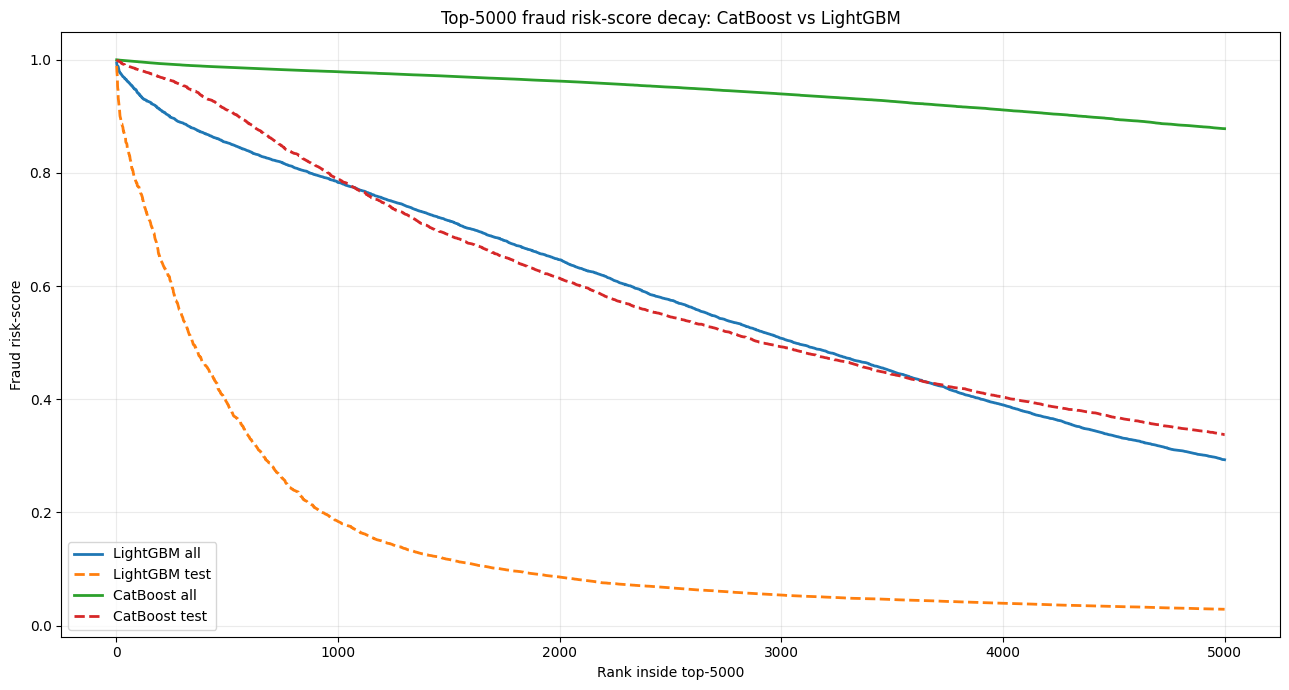

Plot сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_top5000_score_decay.png
Plot сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_top5000_score_decay.svg


In [13]:
curve_rows = []
for label, frame in [
    ("LightGBM all", lightgbm_top5000_all),
    ("LightGBM test", lightgbm_top5000_test),
    ("CatBoost all", catboost_top5000_all),
    ("CatBoost test", catboost_top5000_test),
]:
    tmp = frame[["rank", "fraud_risk_score", "profile_fraud_label"]].copy()
    tmp["line"] = label
    curve_rows.append(tmp)
curve_df = pd.concat(curve_rows, ignore_index=True)
curve_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_top5000_score_curves.csv"
curve_df.to_csv(curve_path, index=False)
print("Curve data сохранено в:", curve_path)

plt.figure(figsize=(13, 7))
for label, frame, linestyle in [
    ("LightGBM all", lightgbm_top5000_all, "-"),
    ("LightGBM test", lightgbm_top5000_test, "--"),
    ("CatBoost all", catboost_top5000_all, "-"),
    ("CatBoost test", catboost_top5000_test, "--"),
]:
    plt.plot(frame["rank"], frame["fraud_risk_score"], label=label, linewidth=2, linestyle=linestyle)

plt.title("Top-5000 fraud risk-score decay: CatBoost vs LightGBM")
plt.xlabel("Rank inside top-5000")
plt.ylabel("Fraud risk-score")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

png_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_top5000_score_decay.png"
svg_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_top5000_score_decay.svg"
plt.savefig(png_path, dpi=180)
plt.savefig(svg_path)
plt.show()

print("Plot сохранено в:", png_path)
print("Plot сохранено в:", svg_path)

In [14]:
def describe_line(name, frame):
    return {
        "line": name,
        "rows": len(frame),
        "fraud_rate": float(frame["profile_fraud_label"].mean()),
        "score_rank_1": float(frame["fraud_risk_score"].iloc[0]),
        "score_rank_100": float(frame["fraud_risk_score"].iloc[min(99, len(frame)-1)]),
        "score_rank_1000": float(frame["fraud_risk_score"].iloc[min(999, len(frame)-1)]),
        "score_rank_5000": float(frame["fraud_risk_score"].iloc[min(4999, len(frame)-1)]),
        "fraud_found_top_100": int(frame.head(100)["profile_fraud_label"].sum()),
        "fraud_found_top_1000": int(frame.head(1000)["profile_fraud_label"].sum()),
        "fraud_found_top_5000": int(frame.head(5000)["profile_fraud_label"].sum()),
    }

сводка_df = pd.DataFrame([
    describe_line("LightGBM all", lightgbm_top5000_all),
    describe_line("LightGBM test", lightgbm_top5000_test),
    describe_line("CatBoost all", catboost_top5000_all),
    describe_line("CatBoost test", catboost_top5000_test),
])
сводка_path = OUTPUT_DIR / "ml_v1_4_catboost_lightgbm_top5000_score_сводка.csv"
сводка_df.to_csv(сводка_path, index=False)
print("Сводка сохранено в:", сводка_path)
display(сводка_df)

Сводка сохранено в: /content/drive/MyDrive/ieee-db/ML/1.4/results_score_compare/ml_v1_4_catboost_lightgbm_top5000_score_сводка.csv


,line,rows,fraud_rate,score_rank_1,score_rank_100,score_rank_1000,score_rank_5000,fraud_found_top_100,fraud_found_top_1000,fraud_found_top_5000
0,LightGBM all,5000,0.7362,0.994487,0.939741,0.782969,0.293072,100,974,3681
1,LightGBM test,5000,0.1570,0.989150,0.775364,0.183973,0.028795,87,498,785
2,CatBoost all,5000,0.6590,0.999791,0.996305,0.978717,0.878097,98,892,3295
3,CatBoost test,5000,0.1542,0.999491,0.981879,0.788493,0.337296,84,484,771


## Как читать график

Линия выше означает, что модель дольше держит высокий fraud risk-score внутри top-5000. Но это не всегда значит, что модель лучше: у CatBoost и LightGBM score может быть по-разному откалиброван. Поэтому график полезен как сравнение формы уверенности, а качество лучше читать вместе с fraud-rate, top-k и test-метриками.

Сравнение `all` и `test` тоже надо читать аккуратно. `all` включает train/val/test, поэтому там модель может выглядеть увереннее. `test` честнее показывает поведение на отложенной части, но top-5000 test - это большая доля test-выборки, поэтому хвост линии обычно падает намного ниже.